1st Test - Human segmentation - Image 000 - 1920x1080


In [69]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [70]:
# Check shape
print(hsv_img.shape) # Result: (1080, 1920, 3)

(1080, 1920, 3)


In [71]:
# Get HSV color value
"""
OpenCV halves the H values to fit the range [0,255], so H value instead of being in range [0, 360], is in range [0, 180].
S and V are still in range [0, 255].
"""
import cv2 as cv
import numpy as np

# RGB => BGR (OpenCV)
# Walker Color: Hex(#ff0c0c) => RGB [255, 12, 12] => HSV (0°, 100%, 52%)
walker_color = np.uint8([[[12, 12, 255]]])   #BGR (OpenCV)
hsv_color = cv.cvtColor(walker_color, cv.COLOR_BGR2HSV)
print(hsv_color) # Expected value: [0, 243, 255] (Hue, Saturation, Value)

[[[  0 243 255]]]


In [72]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [0, 255, 255]
upper_bound = [0, 255, 255]
"""


'\nWriting down values (Hue, Saturation, Value)\nlower_bound = [0, 255, 255]\nupper_bound = [0, 255, 255]\n'

In [73]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [ ]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value) after pre-process
lower_bound = [0, 230, 240]
upper_bound = [176, 255, 255]
"""

'\nWriting down values (Hue, Saturation, Value) after pre-process\nlower_bound = [0, 231, 242]\nupper_bound = [180, 255, 255]\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

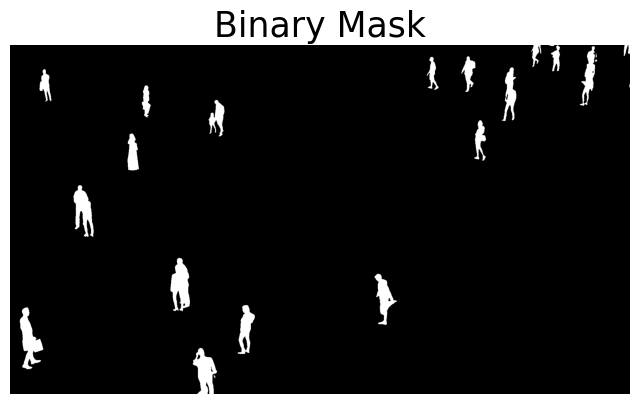

In [ ]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define Human color limits >> HSV (H:0, S:236, V:242) to (H:99, S:255, V:255)
# New values ​​considering preprocessing
# lower_bound = np.array([0, 240, 255]) # Lose details
lower_bound = np.array([0, 230, 240]) # Hue, Saturation, Value
# upper_bound = np.array([0, 255, 255]) # Lose details
upper_bound = np.array([176, 255, 255]) # Hue, Saturation, Value


# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [89]:
# 2.4 - Check Mask Values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

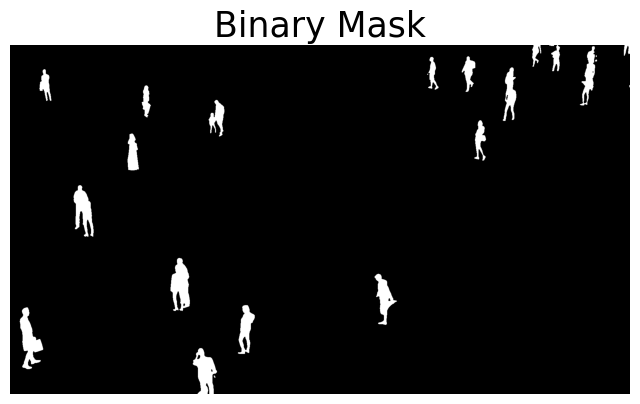

In [90]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

In [91]:
# 3.5 - Check Mask values
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

'\nResult (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled\nUpdate (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects\n\nConsider process and min_area as a factor to refactor the image_manipulation.py\n'

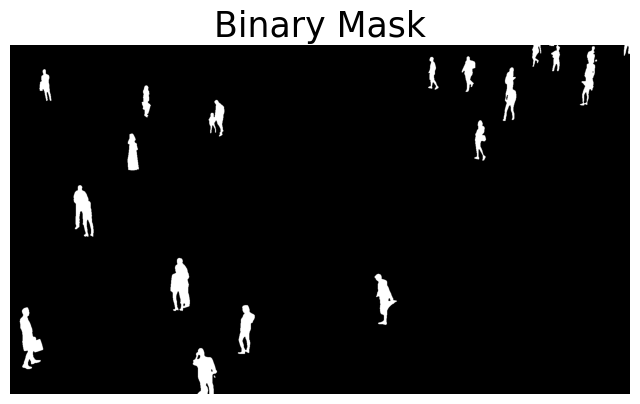

In [92]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled
Update (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

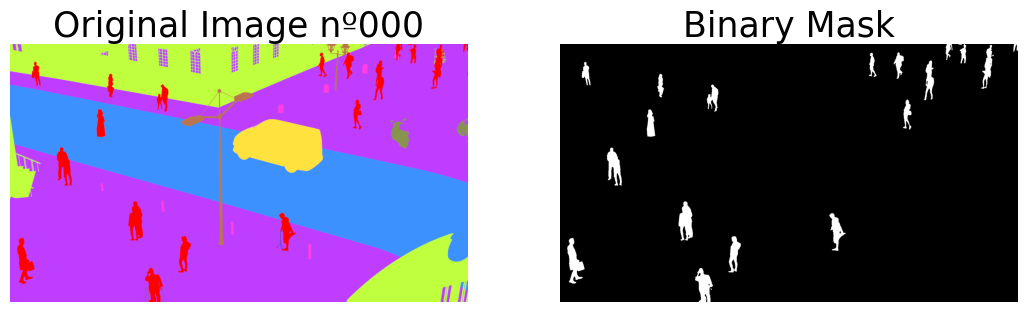

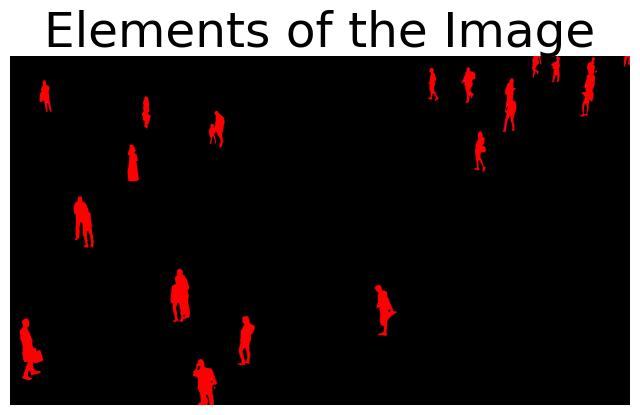

In [93]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [94]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

2nd Test - Human Segmentation - Image 368 - 1920x1080

In [95]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [96]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

In [97]:
# Preprocess
# Apply blur to reduce noise
hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

In [98]:
# Inspect the actual color values ​​in the image for each pixel
cv.imshow("Inspect Image", hsv_img)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 187]
upper_bound = [145, 178, 225]

No changes for now.
"""

'\nWriting down values (Hue, Saturation, Value)\nlower_bound = [142, 148, 187]\nupper_bound = [145, 178, 225]\n\nNo changes for now.\n'

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

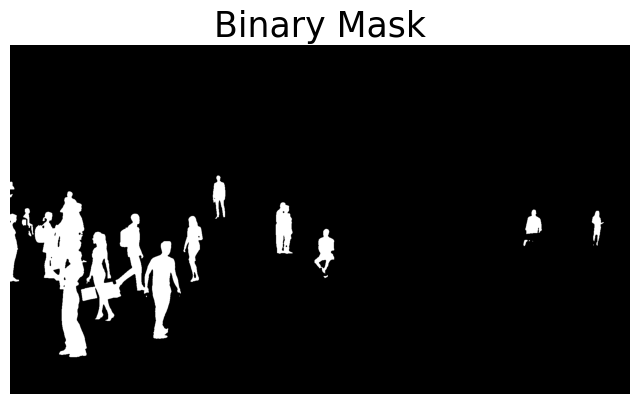

In [ ]:
### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define Human color limits >> HSV (H:0, S:236, V:242) to (H:99, S:255, V:255)
# New values ​​considering preprocessing
lower_bound = np.array([0, 230, 240]) # Hue, Saturation, Value
upper_bound = np.array([176, 255, 255]) # Hue, Saturation, Value


# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

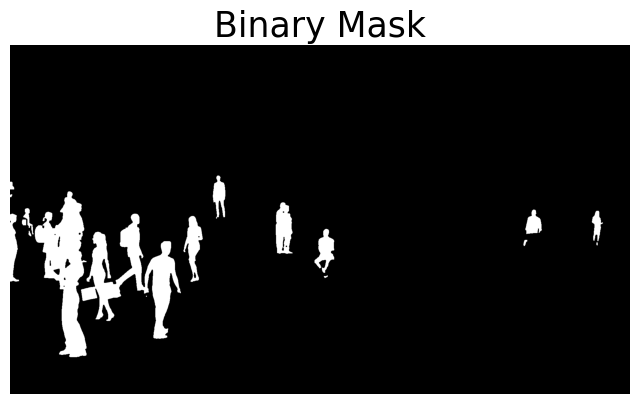

In [100]:
# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

'\nResult (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled\nUpdate (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects\n\nConsider process and min_area as a factor to refactor the image_manipulation.py\n'

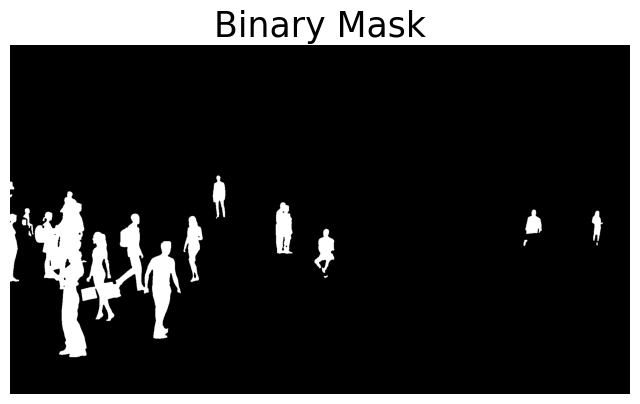

In [101]:
# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

"""
Result (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled
Update (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

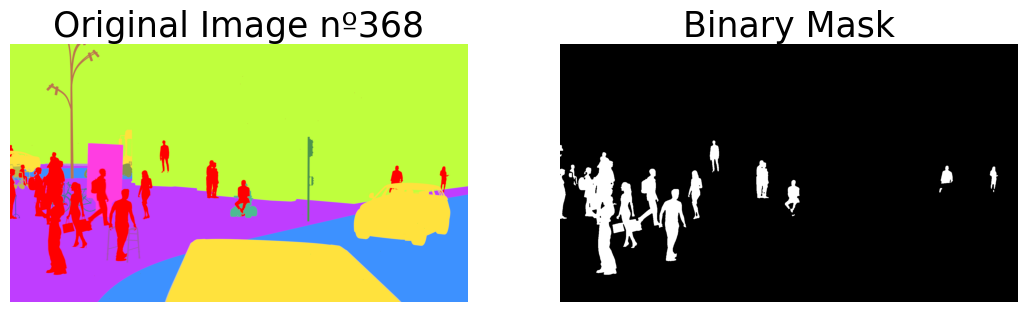

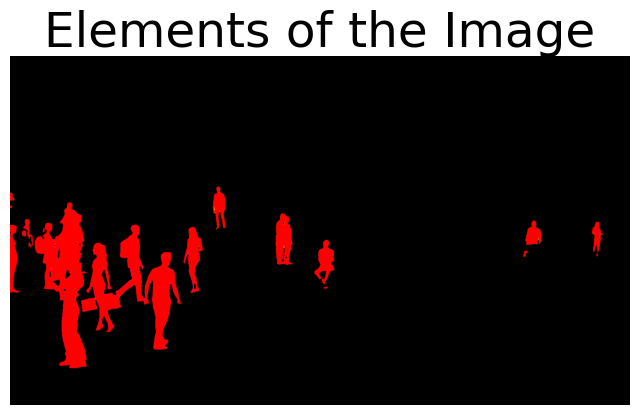

In [102]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [103]:
# 3.5 - Check Result values
cv.imshow("Inspect Result", result)
cv.waitKey(0)
cv.destroyAllWindows()

3rd Test - Human Segmentation - Image 692 (Blur Effect) - 1920x1080

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

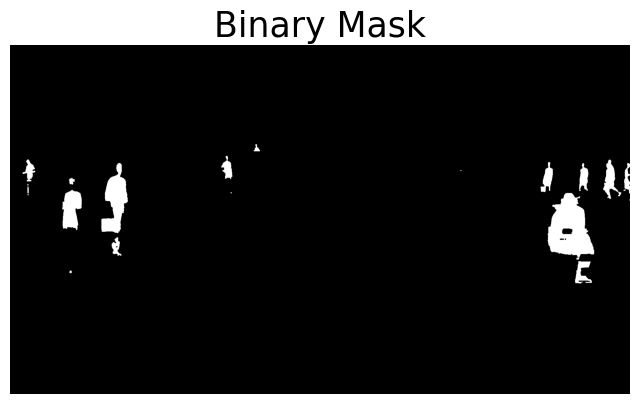

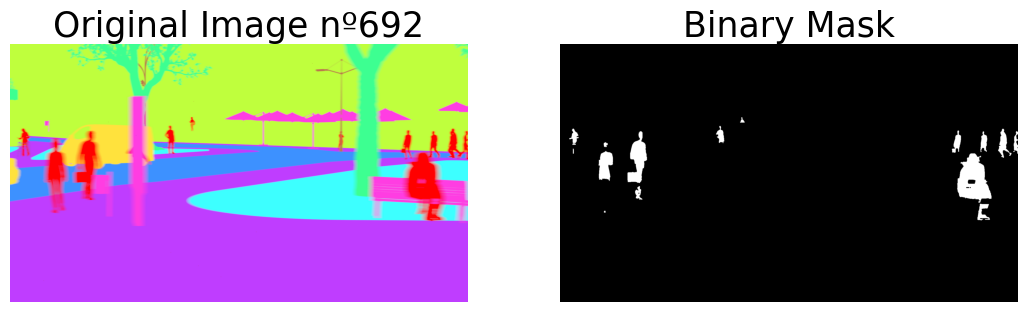

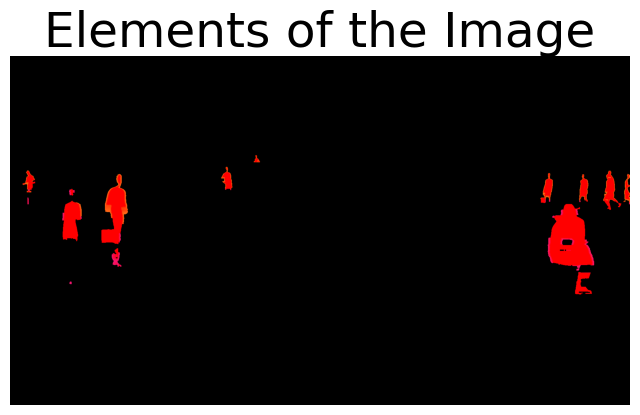

In [ ]:
import sys
import os

# Add the project root folder path to sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Preprocess
# Apply blur to reduce noise
# hsv_img = cv.GaussianBlur(hsv_img, (5,5), 0)

### Process 1 - One Range of HSV Values ###
# First Step - Limits
# 1 - Define Human color limits >> HSV (H:0, S:236, V:242) to (H:99, S:255, V:255)
# New values ​​considering preprocessing
lower_bound = np.array([0, 230, 240]) # Hue, Saturation, Value
upper_bound = np.array([176, 255, 255]) # Hue, Saturation, Value


# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# # 2.3 - Visualize binary mask
# plt.figure(figsize=[8,8])
# plt.imshow(mask, cmap='gray')
# plt.title("Binary Mask",fontdict={'fontsize': 25})
# plt.axis('off')

# Morphologic Operation
# 3. Post-processing
kernel = np.ones((3,3), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)  # Remove small noise
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel) # Close small holes

plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Third Step - Remove Noise
# Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 10

# Filter by area and preserve structure
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        # Create mask for this specific contour
        temp_mask = np.zeros_like(mask)
        cv.drawContours(temp_mask, [contour], -1, (255), -1)
        
        # Preserve original pixels within outline
        contour_region = cv.bitwise_and(mask, temp_mask)
        filtered_mask = cv.bitwise_or(filtered_mask, contour_region)

mask = filtered_mask

# # 3.4 - Visualize updated mask
# plt.figure(figsize=[8,8])
# plt.imshow(mask, cmap='gray')
# plt.title("Binary Mask",fontdict={'fontsize': 25})
# plt.axis('off')

"""
Result (cv.RETR_EXTERNAL): Terrible. Removes noise, but in complex objects the gaps in the object are filled
Update (cv.RETR_TREE): After refactor the code now it is possible filter the noise with complex objects

Consider process and min_area as a factor to refactor the image_manipulation.py
"""

# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[8,8])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')